In [ ]:
 # ==========================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# Dog vs Cat Image Classification using CNN
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [ ]:
# ==========================================
# CELL 2: CHECK COLAB ENVIRONMENT
# ==========================================

print("TensorFlow Version:", tf.__version__)

# Check available GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
    print("GPU is ready for CNN training! 🚀")
else:
    print("No GPU detected.")
    print("The project can still run using CPU.")

TensorFlow Version: 2.20.0
No GPU detected.
The project can still run using CPU.


In [ ]:
# ==========================================
# CELL 4: KAGGLE API AUTHENTICATION
# ==========================================

from google.colab import files
import os
import shutil

print("Please upload your kaggle.json file")

uploaded = files.upload()

# Create Kaggle configuration directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json to the required location
if 'kaggle.json' in uploaded:
    shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Set required permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured successfully! ✅")

Please upload your kaggle.json file


Saving kaggle.json to kaggle.json
Kaggle API configured successfully! ✅


In [ ]:
# ==========================================
# CELL 7: DOWNLOAD KAGGLE DATASET
# ==========================================

!kaggle datasets download -d chetankv/dogs-cats-images

print("Dataset downloaded successfully! ✅")

Dataset URL: https://www.kaggle.com/datasets/chetankv/dogs-cats-images
License(s): CC0-1.0
dogs-cats-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded successfully! ✅


In [ ]:
# ==========================================
# CELL 8: EXTRACT KAGGLE DATASET
# ==========================================

import zipfile
import os

# Find the downloaded zip file
zip_file = "dogs-cats-images.zip"

# Extract dataset
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/dogs_cats_dataset")

print("Dataset extracted successfully! ✅")

# Show extracted folders/files
print("\nDataset contents:")
print(os.listdir("/content/dogs_cats_dataset"))

Dataset extracted successfully! ✅

Dataset contents:
['dataset', 'dog vs cat']


In [ ]:
# ==========================================
# CELL 10: COUNT CAT AND DOG IMAGES
# ==========================================

import os

dataset_path = "/content/dogs_cats_dataset"

cat_count = 0
dog_count = 0

for root, dirs, files in os.walk(dataset_path):

    folder_name = os.path.basename(root).lower()

    image_files = [
        file for file in files
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if folder_name == "cats":
        cat_count += len(image_files)

    elif folder_name == "dogs":
        dog_count += len(image_files)

total_images = cat_count + dog_count

print("Dataset Image Count")
print("--------------------")
print("Cats  :", cat_count)
print("Dogs  :", dog_count)
print("Total :", total_images)

Dataset Image Count
--------------------
Cats  : 10000
Dogs  : 10000
Total : 20000


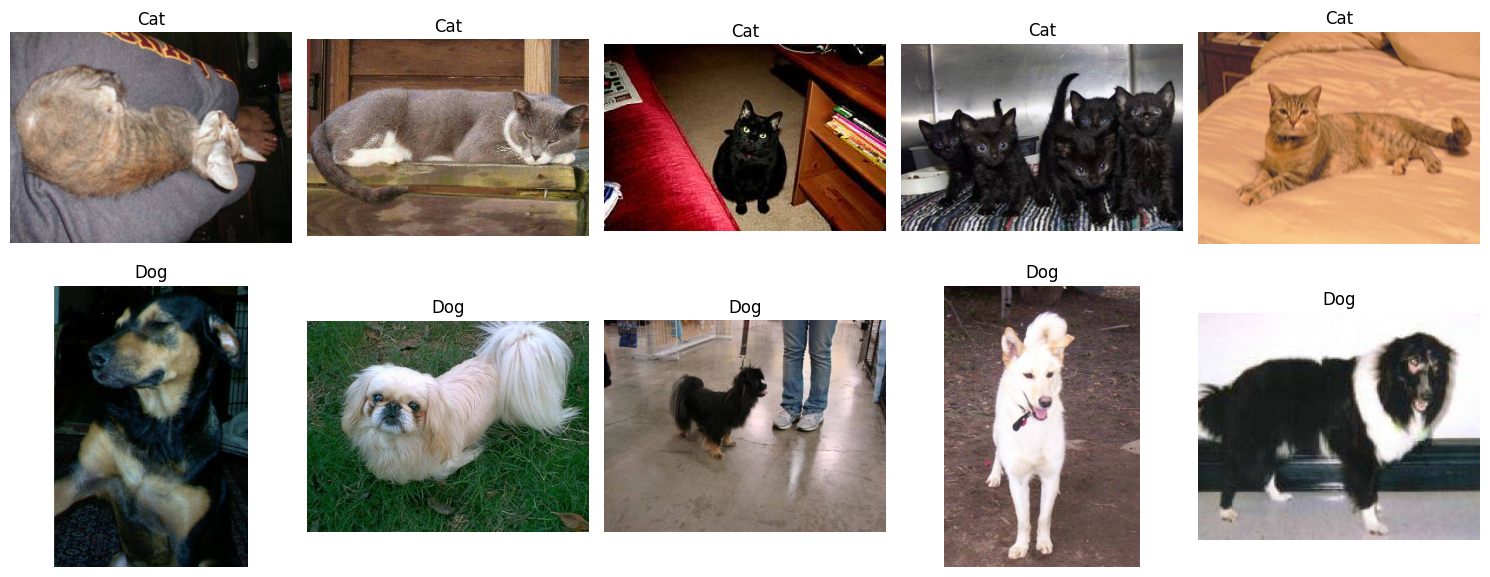

Sample images displayed successfully! ✅


In [ ]:
# ==========================================
# CELL 11: VISUALIZE SAMPLE IMAGES
# ==========================================

import glob
from PIL import Image
import matplotlib.pyplot as plt

# Find cat and dog images
cat_images = glob.glob(
    "/content/dogs_cats_dataset/**/*cats/*.jpg",
    recursive=True
)

dog_images = glob.glob(
    "/content/dogs_cats_dataset/**/*dogs/*.jpg",
    recursive=True
)

# Take first 5 images from each class
sample_cats = cat_images[:5]
sample_dogs = dog_images[:5]

# Combine samples
sample_images = sample_cats + sample_dogs

plt.figure(figsize=(15, 6))

for i, image_path in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")

    if i < 5:
        plt.title("Cat")
    else:
        plt.title("Dog")

plt.tight_layout()
plt.show()

print("Sample images displayed successfully! ✅")

In [ ]:
# ==========================================
# CELL 12: CHECK FOR CORRUPTED IMAGES
# ==========================================

from PIL import Image
import os

dataset_path = "/content/dogs_cats_dataset"

valid_images = 0
corrupted_images = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(root, file)

            try:
                with Image.open(image_path) as img:
                    img.verify()

                valid_images += 1

            except Exception:
                corrupted_images.append(image_path)

print("Image Validation Results")
print("-------------------------")
print("Valid images     :", valid_images)
print("Corrupted images :", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted image files:")
    for image in corrupted_images[:10]:
        print(image)
else:
    print("\nNo corrupted images found! ✅")

Image Validation Results
-------------------------
Valid images     : 20000
Corrupted images : 0

No corrupted images found! ✅


Class Distribution
-------------------
Cats : 10000
Dogs : 10000


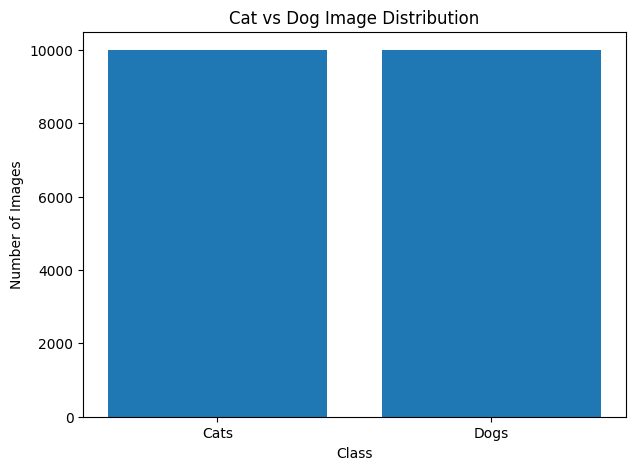

In [ ]:
# ==========================================
# CELL 13: CHECK CLASS DISTRIBUTION
# ==========================================

import os
import matplotlib.pyplot as plt

dataset_path = "/content/dogs_cats_dataset"

cat_count = 0
dog_count = 0

for root, dirs, files in os.walk(dataset_path):

    folder_name = os.path.basename(root).lower()

    image_count = len([
        file for file in files
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if folder_name == "cats":
        cat_count += image_count

    elif folder_name == "dogs":
        dog_count += image_count

# Display counts
print("Class Distribution")
print("-------------------")
print(f"Cats : {cat_count}")
print(f"Dogs : {dog_count}")

# Plot distribution
classes = ["Cats", "Dogs"]
counts = [cat_count, dog_count]

plt.figure(figsize=(7, 5))
plt.bar(classes, counts)

plt.title("Cat vs Dog Image Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
# ==========================================
# CELL 14: IMAGE PREPROCESSING PARAMETERS
# ==========================================

IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

print("Image Height :", IMG_HEIGHT)
print("Image Width  :", IMG_WIDTH)
print("Channels     :", CHANNELS)
print("Image Size   :", IMAGE_SIZE)

Image Height : 128
Image Width  : 128
Channels     : 3
Image Size   : (128, 128)


In [ ]:
# ==========================================
# CELL 18: DATA AUGMENTATION
# ==========================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation created successfully! ✅")

Data augmentation created successfully! ✅


In [ ]:
# ==========================================
# CELL 24:  Splitting CORRECT CAT/DOG DATASET PREPARATION
# ==========================================

import os
import glob
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# ------------------------------------------
# Find all Cat and Dog images
# ------------------------------------------

all_cat_images = glob.glob(
    "/content/dogs_cats_dataset/**/*/cats/*",
    recursive=True
)

all_dog_images = glob.glob(
    "/content/dogs_cats_dataset/**/*/dogs/*",
    recursive=True
)

# Keep only image files
image_extensions = (".jpg", ".jpeg", ".png")

all_cat_images = [
    path for path in all_cat_images
    if path.lower().endswith(image_extensions)
]

all_dog_images = [
    path for path in all_dog_images
    if path.lower().endswith(image_extensions)
]

print("Correct Dataset Detection")
print("==========================")
print("Cat images :", len(all_cat_images))
print("Dog images :", len(all_dog_images))

# ------------------------------------------
# Combine images and labels
# Cat = 0
# Dog = 1
# ------------------------------------------

all_images = np.array(all_cat_images + all_dog_images)
all_labels = np.array(
    [0] * len(all_cat_images) +
    [1] * len(all_dog_images)
)

# ------------------------------------------
# First split:
# 80% Training
# 20% Remaining
# ------------------------------------------

train_paths, remaining_paths, train_labels, remaining_labels = train_test_split(
    all_images,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

# ------------------------------------------
# Second split:
# 10% Validation
# 10% Testing
# ------------------------------------------

validation_paths, test_paths, validation_labels, test_labels = train_test_split(
    remaining_paths,
    remaining_labels,
    test_size=0.50,
    random_state=42,
    stratify=remaining_labels
)

print("\nDataset Split")
print("=============")
print("Training   :", len(train_paths))
print("Validation :", len(validation_paths))
print("Testing    :", len(test_paths))
print("Total      :", len(all_images))

Correct Dataset Detection
Cat images : 10000
Dog images : 10000

Dataset Split
Training   : 16000
Validation : 2000
Testing    : 2000
Total      : 20000


In [ ]:
# ==========================================
# CELL 25: CREATE TENSORFLOW DATASETS
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32


# ------------------------------------------
# Function to load and preprocess images
# ------------------------------------------

def load_and_preprocess_image(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG/PNG image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize image
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Normalize pixel values: 0-255 → 0-1
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


# ------------------------------------------
# Create Training Dataset
# ------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)


# ------------------------------------------
# Create Validation Dataset
# ------------------------------------------

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

validation_dataset = validation_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.batch(BATCH_SIZE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)


# ------------------------------------------
# Create Test Dataset
# ------------------------------------------

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


print("TensorFlow datasets created successfully! ✅")

TensorFlow datasets created successfully! ✅


In [ ]:
# ==========================================
# CELL 26: VERIFY CORRECT DATASETS
# ==========================================

# Get one batch from each dataset
train_images, train_labels = next(iter(train_dataset))
validation_images, validation_labels = next(iter(validation_dataset))
test_images, test_labels = next(iter(test_dataset))

print("Dataset Verification")
print("=====================")

print("\nTraining Dataset")
print("Images shape :", train_images.shape)
print("Labels shape :", train_labels.shape)

print("\nValidation Dataset")
print("Images shape :", validation_images.shape)
print("Labels shape :", validation_labels.shape)

print("\nTesting Dataset")
print("Images shape :", test_images.shape)
print("Labels shape :", test_labels.shape)

print("\nPixel Value Range")
print("Minimum :", tf.reduce_min(train_images).numpy())
print("Maximum :", tf.reduce_max(train_images).numpy())

print("\nDataset verification completed successfully! ✅")

Dataset Verification

Training Dataset
Images shape : (32, 128, 128, 3)
Labels shape : (32,)

Validation Dataset
Images shape : (32, 128, 128, 3)
Labels shape : (32,)

Testing Dataset
Images shape : (32, 128, 128, 3)
Labels shape : (32,)

Pixel Value Range
Minimum : 0.0
Maximum : 1.0

Dataset verification completed successfully! ✅


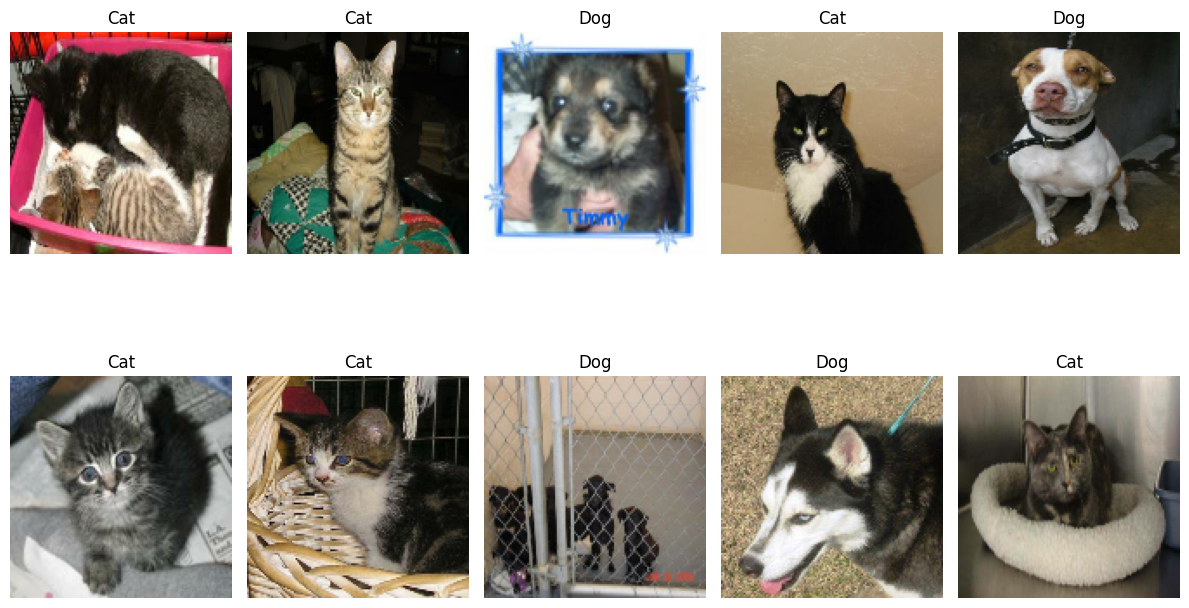

Training samples displayed successfully! ✅


In [ ]:
# ==========================================
# CELL 27: VISUALIZE TRAINING SAMPLES
# ==========================================

import matplotlib.pyplot as plt

# Get one batch of training images
images, labels = next(iter(train_dataset))

plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.axis("off")

    # Label: 0 = Cat, 1 = Dog
    if labels[i].numpy() == 0:
        plt.title("Cat")
    else:
        plt.title("Dog")

plt.tight_layout()
plt.show()

print("Training samples displayed successfully! ✅")

In [ ]:
# ==========================================
# CELL 39: CNN MODEL
# ==========================================

# Create a fresh CNN model
model = keras.Sequential([

    # Input
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    # Data Augmentation
    data_augmentation,

    # --------------------------------------
    # Convolution Block 1
    # --------------------------------------
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # --------------------------------------
    # Convolution Block 2
    # --------------------------------------
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # --------------------------------------
    # Convolution Block 3
    # --------------------------------------
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # --------------------------------------
    # Convolution Block 4
    # --------------------------------------
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # --------------------------------------
    # Classification
    # --------------------------------------
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output
    # 0 = Cat
    # 1 = Dog
    layers.Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN model created successfully! ✅")

Improved CNN model created successfully! ✅


In [ ]:
# ==========================================
# CELL 40: TRAIN  CNN MODEL
# ==========================================

EPOCHS = 15

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    verbose=1
)

print("\nImproved CNN training completed successfully! ✅")

Epoch 1/15
 55/500 ━━━━━━━━━━━━━━━━━━━━ 15:57 2s/step - accuracy: 0.5408 - loss: 2.3457

In [ ]:
# ==========================================
# CELL 41:  CNN TEST EVALUATION
# ==========================================

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\nImproved CNN - Final Test Results")
print("==================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

In [ ]:
# ==========================================
# CELL 42:  CNN CONFUSION MATRIX
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect actual labels and predictions
test_true = []
test_pred = []

for images, labels in test_dataset:

    # Model prediction
    probabilities = model.predict(images, verbose=0).flatten()

    # Default threshold = 0.5
    predictions = (probabilities >= 0.5).astype(int)

    test_true.extend(labels.numpy().flatten())
    test_pred.extend(predictions)

# Convert to NumPy arrays
test_true = np.array(test_true)
test_pred = np.array(test_pred)

# Create confusion matrix
cm = confusion_matrix(
    test_true,
    test_pred
)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()

plt.title("Improved CNN - Confusion Matrix")
plt.show()

print("Improved CNN confusion matrix generated successfully! ✅")

In [ ]:
# ==========================================
# CELL 43: IMPROVED CNN CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

# Generate classification report
improved_report = classification_report(
    test_true,
    test_pred,
    target_names=["Cat", "Dog"],
    digits=4
)

print("Improved CNN - Classification Report")
print("=====================================")
print(improved_report)

In [ ]:
# ==========================================
# CELL 44: IMPROVED CNN TRAINING GRAPHS
# ==========================================

import matplotlib.pyplot as plt

# Get training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)


# ------------------------------------------
# Accuracy Graph
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    label="Validation Accuracy"
)

plt.title("Improved CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------
# Loss Graph
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.title("Improved CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# CELL 46: FIND BEST THRESHOLD
# FOR IMPROVED CNN
# ==========================================

from sklearn.metrics import f1_score
import numpy as np

# Collect validation labels and probabilities
validation_true = []
validation_probabilities = []

for images, labels in validation_dataset:

    probabilities = model.predict(
        images,
        verbose=0
    ).flatten()

    validation_true.extend(
        labels.numpy().flatten()
    )

    validation_probabilities.extend(
        probabilities
    )

# Convert to NumPy arrays
validation_true = np.array(validation_true)
validation_probabilities = np.array(
    validation_probabilities
)

# Search thresholds
thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

best_threshold = 0.50
best_f1 = 0.0

for threshold in thresholds:

    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    score = f1_score(
        validation_true,
        predictions
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Improved CNN Threshold Optimization")
print("====================================")
print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1-Score  : {best_f1:.4f}")

In [ ]:
# ==========================================
# CELL 47: FINAL OPTIMIZED TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Collect test labels and probabilities
test_true = []
test_probabilities = []

for images, labels in test_dataset:

    probabilities = model.predict(
        images,
        verbose=0
    ).flatten()

    test_true.extend(
        labels.numpy().flatten()
    )

    test_probabilities.extend(
        probabilities
    )

# Convert to NumPy arrays
test_true = np.array(test_true)
test_probabilities = np.array(test_probabilities)

# Apply optimized threshold
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

# Calculate final metrics
final_accuracy = accuracy_score(
    test_true,
    test_predictions
)

final_precision = precision_score(
    test_true,
    test_predictions
)

final_recall = recall_score(
    test_true,
    test_predictions
)

final_f1 = f1_score(
    test_true,
    test_predictions
)

final_cm = confusion_matrix(
    test_true,
    test_predictions
)

print("FINAL OPTIMIZED TEST RESULTS")
print("============================")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {final_accuracy * 100:.2f}%")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

In [ ]:
# ==========================================
# CELL 48: FINAL CONFUSION MATRIX
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Cat", "Dog"]
)

# Plot
disp.plot()

plt.title(
    f"Final Confusion Matrix\n"
    f"Optimized Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("Final confusion matrix displayed successfully! ✅")

In [ ]:
# ==========================================
# CELL 49: SAVE TRAINED CNN MODEL
# ==========================================

# Save the trained CNN model
model.save("/content/dog_cat_cnn_model.keras")

print("CNN model saved successfully! ✅")
print("File: dog_cat_cnn_model.keras")

In [ ]:
# ==========================================
# CELL 50: SAVE OPTIMIZED THRESHOLD
# ==========================================

import json

# Save the optimized threshold
threshold_data = {
    "threshold": float(best_threshold)
}

with open("/content/dog_cat_threshold.json", "w") as file:
    json.dump(threshold_data, file, indent=4)

print("Optimized threshold saved successfully! ✅")
print(f"Threshold: {best_threshold:.2f}")
print("File: dog_cat_threshold.json")

In [ ]:
# ==========================================
# CELL 51: LOAD SAVED MODEL AND THRESHOLD
# ==========================================

import tensorflow as tf
import json
import os

# Load saved CNN model
loaded_model = tf.keras.models.load_model(
    "/content/dog_cat_cnn_model.keras"
)

# Load saved threshold
with open("/content/dog_cat_threshold.json", "r") as file:
    threshold_data = json.load(file)

loaded_threshold = threshold_data["threshold"]

print("Saved model loaded successfully! ✅")
print(f"Loaded Threshold: {loaded_threshold:.2f}")

# Check files
print("\nSaved Files:")
print("Model     :", os.path.exists("/content/dog_cat_cnn_model.keras"))
print("Threshold :", os.path.exists("/content/dog_cat_threshold.json"))

In [ ]:
# ==========================================
# CELL 53: DOWNLOAD TRAINED MODEL
# ==========================================

from google.colab import files

files.download("/content/dog_cat_cnn_model.keras")

In [ ]:
# ==========================================
# CELL 54: DOWNLOAD THRESHOLD
# ==========================================

from google.colab import files

files.download("/content/dog_cat_threshold.json")

In [ ]:
# ==========================================
# CELL 55: FINAL  PREDICTION FUNCTION (Reusable)
# ==========================================

def predict_dog_or_cat(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize
    image_resized = image.resize(
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Convert to NumPy
    image_array = np.array(image_resized)

    # Normalize
    image_array = (
        image_array.astype("float32") / 255.0
    )

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Prediction
    probability = float(
        loaded_model.predict(
            image_array,
            verbose=0
        )[0][0]
    )

    # Classification
    if probability >= loaded_threshold:

        predicted_class = "Dog"
        confidence = probability * 100

    else:

        predicted_class = "Cat"
        confidence = (1 - probability) * 100

    # Display
    plt.figure(figsize=(6, 6))

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()

    # Print result
    print("===================================")
    print("        FINAL CNN PREDICTION")
    print("===================================")
    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence:.2f}%")
    print(f"Threshold  : {loaded_threshold:.2f}")
    print("===================================")

    return predicted_class, confidence

In [ ]:
# ==========================================
# CELL 56: FINAL USER IMAGE PREDICTION
# ==========================================

from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file
image_path = list(uploaded.keys())[0]

# Predict
predict_dog_or_cat(image_path)

In [ ]:
# ==========================================
# CELL 58: FINAL PROJECT RESULTS
# ==========================================

print("==============================================")
print("        DOG vs CAT CNN CLASSIFICATION")
print("==============================================")

print("\nModel Architecture")
print("-------------------")
print("Type        : CNN From Scratch")
print("Input Size  : 128 x 128 x 3")
print("Classes     : Cat, Dog")

print("\nDataset")
print("-------")
print("Total Images : 20,000")
print("Training     : 16,000")
print("Validation   : 2,000")
print("Testing      : 2,000")

print("\nFinal Performance")
print("-----------------")
print(f"Accuracy     : {final_accuracy * 100:.2f}%")
print(f"Precision    : {final_precision:.4f}")
print(f"Recall       : {final_recall:.4f}")
print(f"F1-Score     : {final_f1:.4f}")

print("\nOptimized Threshold")
print("-------------------")
print(f"Threshold    : {best_threshold:.2f}")

print("\n==============================================")
print("         PROJECT COMPLETED SUCCESSFULLY! ✅")
print("==============================================")

In [ ]:
# ==========================================
# CELL 59: CHECK PROJECT FILES
# ==========================================

import os

project_files = [
    "/content/dog_cat_cnn_model.keras",
    "/content/dog_cat_threshold.json"
]

print("Saved Project Files")
print("===================")

for file_path in project_files:

    if os.path.exists(file_path):

        size_mb = (
            os.path.getsize(file_path)
            / (1024 * 1024)
        )

        print(
            f"✅ {os.path.basename(file_path)} "
            f"({size_mb:.2f} MB)"
        )

    else:

        print(
            f"❌ {os.path.basename(file_path)} "
            "not found"
        )